In [46]:
import eurostat
import pandas as pd

In [47]:
# 1. Define the dataset code
ds_asyl_code = 'migr_asyappctza'

# 2. Download the data programmatically
df_asyl_raw = eurostat.get_data_df(ds_asyl_code)

# 3. Apply the EXACT filters you planned
df_asyl_filtered = df_asyl_raw[
    (df_asyl_raw['age'] == 'TOTAL') &
    (df_asyl_raw['sex'] == 'T') &
    (df_asyl_raw['unit'] == 'PER') &
    (df_asyl_raw['citizen'] == 'TOTAL') &
    (df_asyl_raw['applicant'] == 'FRST')   # first‑time applicants (valid code)
]

# Rename geo column
df_asyl_filtered = df_asyl_filtered.rename(columns={'geo\\TIME_PERIOD': 'geo'})

# 4. Keep only years 2013–2022
years = [str(y) for y in range(2013, 2023)]
cols = ['geo'] + years
df_asyl_final = df_asyl_filtered[cols].copy()

# 5. Wide → long
df_asyl_long = df_asyl_final.melt(
    id_vars='geo',
    value_vars=years,
    var_name='year',
    value_name='asylum_applicants'
)
df_asyl_long['year'] = df_asyl_long['year'].astype(int)
df_asyl_long = df_asyl_long.sort_values(['geo', 'year'])

# Backward fill values
df_asyl_long['asylum_applicants'] = (
    df_asyl_long.groupby('geo')['asylum_applicants'].bfill()
)

display(df_asyl_long)


,geo,year,asylum_applicants
0,AT,2013,25700.0
34,AT,2014,25700.0
68,AT,2015,85520.0
102,AT,2016,39905.0
136,AT,2017,22470.0
...,...,...,...
203,UK,2018,38485.0
237,UK,2019,44315.0
271,UK,2020,NaN
305,UK,2021,NaN


In [48]:
pop_code = 'demo_pjan'
df_pop_raw = eurostat.get_data_df(pop_code)

df_pop = df_pop_raw[
    (df_pop_raw['age'] == 'TOTAL') &
    (df_pop_raw['sex'] == 'T') &
    (df_pop_raw['unit'] == 'NR')
]

df_pop = df_pop.rename(columns={'geo\\TIME_PERIOD': 'geo'})

years = [str(y) for y in range(2013, 2023)]
cols = ['geo'] + years
df_pop = df_pop[cols].copy()

df_pop_long = df_pop.melt(
    id_vars='geo',
    value_vars=years,
    var_name='year',
    value_name='population'
)
df_pop_long['year'] = df_pop_long['year'].astype(int)

# Print NaNs before backward fill
nans_before = df_pop_long['population'].isna().sum()
print(f"NaNs in df_pop_long['population'] before backward fill: {nans_before}")

# Backward fill population within each country over years
df_pop_long = df_pop_long.sort_values(['geo', 'year'])
df_pop_long['population'] = (
    df_pop_long.groupby('geo')['population'].bfill()
)

# Print NaNs after backward fill
nans_after = df_pop_long['population'].isna().sum()
print(f"NaNs in df_pop_long['population'] after backward fill: {nans_after}")

NaNs in df_pop_long['population'] before backward fill: 78
NaNs in df_pop_long['population'] after backward fill: 58


In [49]:
display(df_pop_long)

,geo,year,population
0,AD,2013,76246.0
59,AD,2014,76177.0
118,AD,2015,76177.0
177,AD,2016,76177.0
236,AD,2017,76177.0
...,...,...,...
353,XK,2018,1798506.0
412,XK,2019,1795666.0
471,XK,2020,1782115.0
530,XK,2021,1798186.0


In [50]:
df_merged = df_asyl_long.merge(df_pop_long, on=['geo', 'year'], how='inner')
df_merged['asylum_per_100k'] = df_merged['asylum_applicants'] / df_merged['population'] * 100_000

In [51]:
# Drop aggregate EU and selected countries (UK, Iceland, Montenegro)
exclude_geo = ['EU27_2020', 'UK', 'IS','ME']
df_merged = df_merged[~df_merged['geo'].isin(exclude_geo)].copy()

In [52]:
# Static mapping for common Eurostat geo codes
geo_map = {
    "AT": "Austria",
    "BE": "Belgium",
    "BG": "Bulgaria",
    "HR": "Croatia",
    "CY": "Cyprus",
    "CZ": "Czechia",
    "DK": "Denmark",
    "EE": "Estonia",
    "FI": "Finland",
    "FR": "France",
    "DE": "Germany",
    "EL": "Greece",
    "GR": "Greece",
    "HU": "Hungary",
    "IE": "Ireland",
    "IT": "Italy",
    "LV": "Latvia",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "MT": "Malta",
    "NL": "Netherlands",
    "PL": "Poland",
    "PT": "Portugal",
    "RO": "Romania",
    "SK": "Slovakia",
    "SI": "Slovenia",
    "ES": "Spain",
    "LI": "Liechtenstein",
    "SE": "Sweden",
    "NO": "Norway",
    "CH": "Switzerland",
}
df_merged['country'] = df_merged['geo'].map(geo_map).fillna(df_merged['geo'])

In [53]:
display(df_merged)

,geo,year,asylum_applicants,population,asylum_per_100k,country
0,AT,2013,25700.0,8451860.0,304.075079,Austria
1,AT,2014,25700.0,8507786.0,302.076239,Austria
2,AT,2015,85520.0,8584926.0,996.164673,Austria
3,AT,2016,39905.0,8700471.0,458.653330,Austria
4,AT,2017,22470.0,8772865.0,256.130694,Austria
...,...,...,...,...,...,...
325,SK,2018,155.0,5443120.0,2.847632,Slovakia
326,SK,2019,215.0,5450421.0,3.944649,Slovakia
327,SK,2020,265.0,5457873.0,4.855371,Slovakia
328,SK,2021,330.0,5459781.0,6.044198,Slovakia


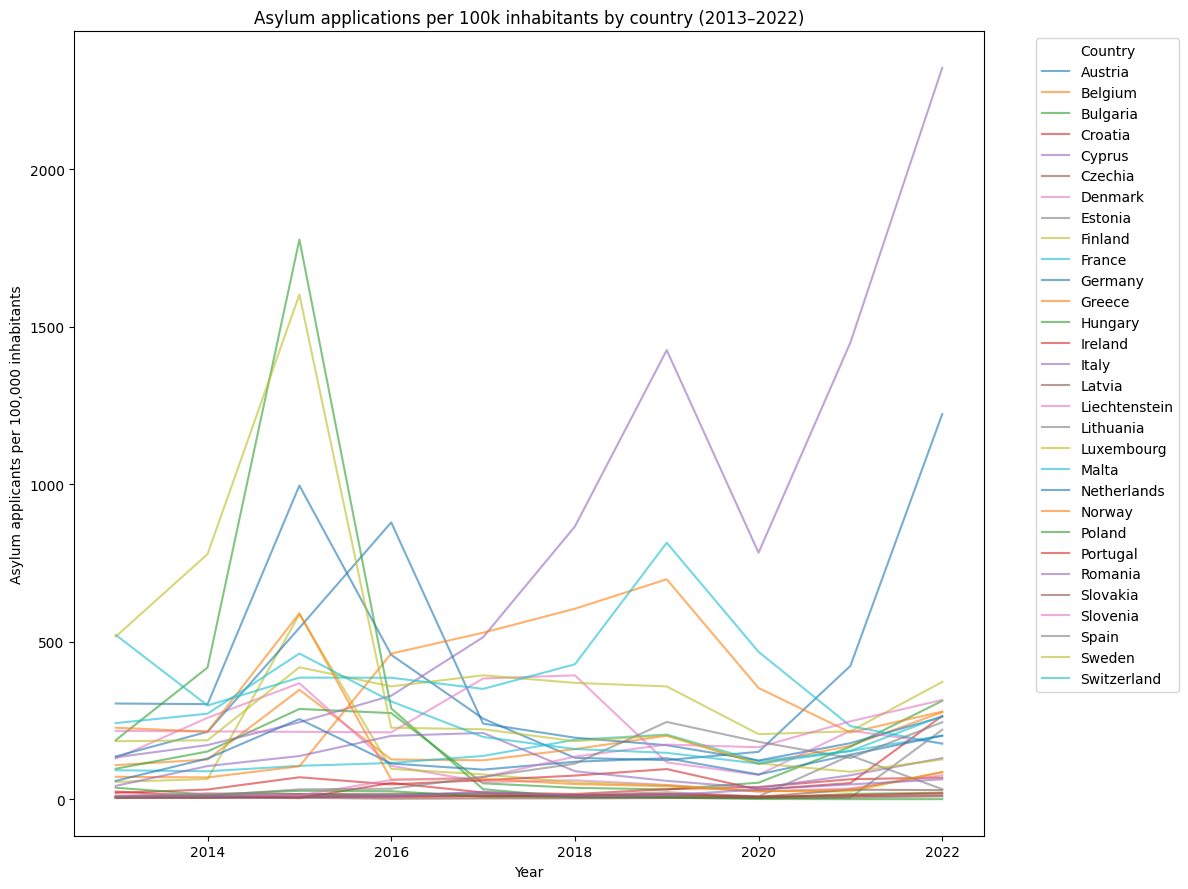

In [54]:
import matplotlib.pyplot as plt

# Line plot of asylum applications per 100k by country over time
plt.figure(figsize=(12, 9))
for country, group in df_merged.groupby('country'):
    plt.plot(group['year'], group['asylum_per_100k'], label=country, alpha=0.6)

plt.xlabel('Year')
plt.ylabel('Asylum applicants per 100,000 inhabitants')
plt.title('Asylum applications per 100k inhabitants by country (2013–2022)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [55]:
# Download and prepare Eurostat crime data (crim_off_cat)
ds_crime_code = 'crim_off_cat'
df_crime_raw = eurostat.get_data_df(ds_crime_code)

# ICCS codes considered as (broadly) violent/serious crime
crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0102': 'Attempted intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS03012': 'Sexual assault',
    'ICCS0401': 'Robbery',
    'ICCS0501': 'Burglary (and subcategories)',
    'ICCS0502': 'Theft (and subcategories)',
}

# Filter by unit (per 100k inhabitants) and selected ICCS categories
df_crime_filtered = df_crime_raw[
    (df_crime_raw['unit'] == 'P_HTHAB') &
    (df_crime_raw['iccs'].isin(crime_codes.keys()))
]

# Rename geo column
df_crime_filtered = df_crime_filtered.rename(columns={'geo\\TIME_PERIOD': 'geo'})

# Keep only countries present in geo_map (drop aggregates/others)
df_crime_filtered = df_crime_filtered[df_crime_filtered['geo'].isin(geo_map.keys())].copy()

# Keep only years 2013–2022
years = [str(y) for y in range(2013, 2023)]
cols = ['geo', 'iccs'] + years
df_crime_wide = df_crime_filtered[cols].copy()

# Wide → long (one row per geo-year-ICCS)
df_crime_long = df_crime_wide.melt(
    id_vars=['geo', 'iccs'],
    value_vars=years,
    var_name='year',
    value_name='crime_rate_per_100k',
)
df_crime_long['year'] = df_crime_long['year'].astype(int)

# Pivot so each ICCS has its own column, preserving NaNs
df_crime_pivot = df_crime_long.pivot(
    index=['geo', 'year'],
    columns='iccs',
    values='crime_rate_per_100k',
)
df_crime_pivot.columns.name = None  # drop the column index name

# Total crime per 100k as sum of selected ICCS columns
df_crime_pivot['crime_per_100k'] = df_crime_pivot.sum(axis=1, min_count=1)
df_crime_agg = df_crime_pivot.reset_index()

In [56]:
# Final dataframe: merge asylum + population + violent crime data
df_final = df_merged.merge(df_crime_agg, on=['geo', 'year'], how='inner')
display(df_final)

,geo,year,asylum_applicants,population,asylum_per_100k,country,ICCS0101,ICCS0102,ICCS0301,ICCS03011,ICCS03012,ICCS0401,ICCS0501,ICCS0502,crime_per_100k
0,AT,2013,25700.0,8451860.0,304.075079,Austria,0.75,1.24,44.72,15.32,25.47,44.22,1049.51,1822.11,3003.34
1,AT,2014,25700.0,8507786.0,302.076239,Austria,0.51,0.82,41.90,13.68,24.91,40.92,1004.91,1742.86,2870.51
2,AT,2015,85520.0,8584926.0,996.164673,Austria,0.49,1.12,40.57,13.18,23.43,39.79,922.92,1635.37,2676.87
3,AT,2016,39905.0,8700471.0,458.653330,Austria,0.56,1.14,50.53,14.17,32.46,35.66,926.38,1651.67,2712.57
4,AT,2017,22470.0,8772865.0,256.130694,Austria,0.70,1.72,48.48,17.01,27.55,29.75,789.47,1501.41,2416.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,SK,2018,155.0,5443120.0,2.847632,Slovakia,1.23,NaN,12.25,1.82,1.40,8.73,83.19,316.58,425.20
296,SK,2019,215.0,5450421.0,3.944649,Slovakia,1.39,NaN,12.81,1.78,1.43,7.52,67.79,271.47,364.19
297,SK,2020,265.0,5457873.0,4.855371,Slovakia,1.15,NaN,11.34,1.69,1.08,5.95,68.25,256.57,346.03
298,SK,2021,330.0,5459781.0,6.044198,Slovakia,1.01,NaN,10.82,1.69,1.32,5.29,59.47,179.48,259.08


In [57]:
# Check missing values (NaNs) in asylum and crime data
asyl_total_count = df_asyl_long['asylum_applicants'].size
asyl_nan_count = df_asyl_long['asylum_applicants'].isna().sum()
print(f"Asylum applicants - total cells: {asyl_total_count}")
print(f"Asylum applicants - NaN count: {asyl_nan_count}\n")

crime_stats_per_code = (
    df_crime_long.groupby('iccs')['crime_rate_per_100k']
    .agg(total_count='size', nan_count=lambda s: s.isna().sum())
    .reset_index()
)

print("NaN and total counts in crime_rate_per_100k per ICCS code:")
display(crime_stats_per_code)

Asylum applicants - total cells: 340
Asylum applicants - NaN count: 3

NaN and total counts in crime_rate_per_100k per ICCS code:


,iccs,total_count,nan_count
0,ICCS0101,300,1
1,ICCS0102,290,18
2,ICCS0301,300,0
3,ICCS03011,290,0
4,ICCS03012,300,29
5,ICCS0401,300,0
6,ICCS0501,280,15
7,ICCS0502,300,0


In [58]:
cols_core = ['geo', 'country', 'year', 'asylum_per_100k', 'crime_per_100k']
df_core = df_final[cols_core].copy()
coverage = (
    df_core
    .groupby('country')[['asylum_per_100k', 'crime_per_100k']]
    .apply(lambda g: (~g.isna()).mean())   # fraction of non‑missing
    .reset_index()
)
display(coverage)

,country,asylum_per_100k,crime_per_100k
0,Austria,1.0,1.0
1,Belgium,1.0,1.0
2,Bulgaria,1.0,1.0
3,Croatia,1.0,1.0
4,Cyprus,1.0,1.0
5,Czechia,1.0,1.0
6,Denmark,1.0,1.0
7,Estonia,1.0,1.0
8,Finland,1.0,1.0
9,France,1.0,1.0


In [59]:
# Coverage of crime data by country and ICCS code
df_crime_long_cov = df_crime_long.copy()
df_crime_long_cov['country'] = df_crime_long_cov['geo'].map(geo_map).fillna(df_crime_long_cov['geo'])

coverage_country_iccs = (
    df_crime_long_cov
    .groupby(['country', 'iccs'])['crime_rate_per_100k']
    .agg(total_observations='size', non_missing=lambda s: s.notna().sum())
    .reset_index()
 )
coverage_country_iccs['coverage_share'] = (
    coverage_country_iccs['non_missing'] / coverage_country_iccs['total_observations']
 )

print("Coverage by country and ICCS code (per-year observations):")
display(coverage_country_iccs)

coverage_iccs_summary = (
    coverage_country_iccs
    .groupby('iccs')
    .agg(
        countries_with_data=('country', 'nunique'),
        avg_coverage_share=('coverage_share', 'mean'),
        min_coverage_share=('coverage_share', 'min'),
    )
    .reset_index()
 )

print("\nSummary coverage per ICCS code across countries:")
display(coverage_iccs_summary)

Coverage by country and ICCS code (per-year observations):


,country,iccs,total_observations,non_missing,coverage_share
0,Austria,ICCS0101,10,10,1.0
1,Austria,ICCS0102,10,10,1.0
2,Austria,ICCS0301,10,10,1.0
3,Austria,ICCS03011,10,10,1.0
4,Austria,ICCS03012,10,10,1.0
...,...,...,...,...,...
231,Switzerland,ICCS03011,10,10,1.0
232,Switzerland,ICCS03012,10,10,1.0
233,Switzerland,ICCS0401,10,10,1.0
234,Switzerland,ICCS0501,10,10,1.0



Summary coverage per ICCS code across countries:


,iccs,countries_with_data,avg_coverage_share,min_coverage_share
0,ICCS0101,30,0.996667,0.9
1,ICCS0102,29,0.937931,0.1
2,ICCS0301,30,1.000000,1.0
3,ICCS03011,29,1.000000,1.0
4,ICCS03012,30,0.903333,0.3
5,ICCS0401,30,1.000000,1.0
6,ICCS0501,28,0.946429,0.2
7,ICCS0502,30,1.000000,1.0
